<a href="https://colab.research.google.com/github/TienPhap0102/Traffic-to-Value-A-Full-Funnel-Analysis-of-User-Journey-Retention/blob/main/Sankey_Flow_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Traffic-to-Value: A Full-Funnel Analysis of User Journey & Retention**

**Business Overview**

In an e-commerce landscape where Customer Acquisition Cost (CAC) is increasingly expensive, merely tracking website traffic or total orders is no longer sufficient to evaluate business performance. The Marketing department needs to clearly understand the "flow of customers from the advertising source to the final purchase".

In reality, a significant portion of the budget might be wasted on traffic sources with high drop-off rates or on acquiring one-time buyers. To optimize Return on Investment (ROI), the business must dive deeper into user behavior data on the website (sessions, pageviews). We need a comprehensive picture: from the very first click at the top of the funnel (Acquisition) to the ability to retain customers at the bottom of the funnel (Retention).

**Objectives**

This project is implemented to address the core business problems through two powerful analytical approaches:

* **Sankey Diagram:** Focuses on the Acquisition and Activation stages. This diagram will trace the customer flow from the marketing source $\rightarrow$ the first touchpoint $\rightarrow$ the purchased product or abandonment. This helps evaluate which channel brings in the highest quality traffic and which website page causes the most customer drop-offs.

* **Cohort Analysis:** Focuses on the Retention and Revenue stages. By grouping customers based on their first purchase month, this analysis answers the crucial question:
  * Do customers return to make subsequent purchases in the following months?
  * What is the Customer Lifetime Value (LTV) generated by each cohort over time?
  

# **1. Set up & Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go

# **2. Import Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**`orders table`**

In [ ]:
orders = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 9 - Sankey Flow/Data/orders.csv')
orders.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


**`products table`**

In [ ]:
products = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 9 - Sankey Flow/Data/products.csv')
products

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


**`sessions table`**

In [ ]:
sessions = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 9 - Sankey Flow/Data/website_sessions.csv')
sessions

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
...,...,...,...,...,...,...,...,...,...
472866,472867,2015-03-19 07:49:25,394314,0,gsearch,brand,g_ad_2,desktop,https://www.gsearch.com
472867,472868,2015-03-19 07:54:36,394315,0,bsearch,nonbrand,b_ad_1,mobile,https://www.bsearch.com
472868,472869,2015-03-19 07:55:40,394316,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
472869,472870,2015-03-19 07:56:29,394317,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com


**`pageview table`**

In [ ]:
page_view = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 9 - Sankey Flow/Data/website_pageviews.csv')
page_view

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home
...,...,...,...,...
1188119,1188120,2015-03-19 07:57:32,472866,/shipping
1188120,1188121,2015-03-19 07:58:13,472870,/the-original-mr-fuzzy
1188121,1188122,2015-03-19 07:59:07,472866,/billing-2
1188122,1188123,2015-03-19 07:59:08,472871,/home


**`Order items table`**

In [ ]:
order_items = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 9 - Sankey Flow/Data/order_items.csv')
order_items

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49
...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49


**`Order item refunds table`**

In [ ]:
refunds = pd.read_csv('/content/drive/MyDrive/1. DATA ANH TÚ/Buổi 9 - Sankey Flow/Data/order_item_refunds.csv')
refunds

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99
...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99
1727,1728,2015-03-30 21:33:51,39671,32049,49.99
1728,1729,2015-03-31 19:59:48,39729,32090,49.99
1729,1730,2015-04-01 03:54:48,39717,32079,59.99


# **3. Data Processing**

## **3.1. `orders table`**

In [ ]:
# overview
orders.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB


In [ ]:
# Check duplicate
orders.duplicated().sum()

np.int64(0)

In [ ]:
# Column stats
orders.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,32313.0,16157.000000,9328.103961,1.00,8079.00,16157.00,24235.00,32313.00
website_session_id,32313.0,258292.288707,132427.649842,20.00,144828.00,263554.00,374799.00,472818.00
user_id,32313.0,215691.622629,108402.203189,13.00,124135.00,221461.00,310542.00,394273.00
primary_product_id,32313.0,1.392474,0.732277,1.00,1.00,1.00,2.00,4.00
items_purchased,32313.0,1.238666,0.426274,1.00,1.00,1.00,1.00,2.00
price_usd,32313.0,59.991636,17.808771,29.99,49.99,49.99,59.99,109.98
cogs_usd,32313.0,22.355406,6.238621,9.49,19.49,19.49,22.49,41.98


**Observation:**
- 32313 data rows + 8 columns
- No null values
- No duplicate values
- Matching data types

## **3.2. `sessions table`**

In [ ]:
# overview
sessions.head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [ ]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   created_at          472871 non-null  object
 2   user_id             472871 non-null  int64 
 3   is_repeat_session   472871 non-null  int64 
 4   utm_source          389543 non-null  object
 5   utm_campaign        389543 non-null  object
 6   utm_content         389543 non-null  object
 7   device_type         472871 non-null  object
 8   http_referer        432954 non-null  object
dtypes: int64(3), object(6)
memory usage: 32.5+ MB


In [ ]:
# Check duplicate
sessions.duplicated().sum()

np.int64(0)

In [ ]:
# Check null
sessions.isnull().sum()

,0
website_session_id,0
created_at,0
user_id,0
is_repeat_session,0
utm_source,83328
utm_campaign,83328
utm_content,83328
device_type,0
http_referer,39917


**Observation:**
- 472871 data rows + 9 columns
- No duplicate values
- Matching data types
- There are null values in column: `utm_source`, `utm_campaign`, `utm_content`, `http_referer` $\rightarrow$ Customers buy products even without receiving advertisements $\rightarrow$ **Organic**

In [ ]:
# Fill Null value
sessions['utm_source'] = sessions['utm_source'].fillna('Organic')
sessions['utm_campaign'] = sessions['utm_campaign'].fillna('Organic')
sessions['utm_content'] = sessions['utm_content'].fillna('Organic')
sessions['http_referer'] = sessions['http_referer'].fillna('Unknown')
sessions.isnull().sum()

,0
website_session_id,0
created_at,0
user_id,0
is_repeat_session,0
utm_source,0
utm_campaign,0
utm_content,0
device_type,0
http_referer,0


## **3.3. `pageview table`**

In [ ]:
# overview
page_view

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home
...,...,...,...,...
1188119,1188120,2015-03-19 07:57:32,472866,/shipping
1188120,1188121,2015-03-19 07:58:13,472870,/the-original-mr-fuzzy
1188121,1188122,2015-03-19 07:59:07,472866,/billing-2
1188122,1188123,2015-03-19 07:59:08,472871,/home


In [ ]:
page_view.groupby(by = 'pageview_url').count()

,website_pageview_id,created_at,website_session_id
pageview_url,,,
/billing,3617,3617,3617
/billing-2,48441,48441,48441
/cart,94953,94953,94953
/home,137576,137576,137576
/lander-1,47574,47574,47574
/lander-2,131170,131170,131170
/lander-3,79000,79000,79000
/lander-4,9385,9385,9385
/lander-5,68166,68166,68166


In [ ]:
page_view.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   website_pageview_id  1188124 non-null  int64 
 1   created_at           1188124 non-null  object
 2   website_session_id   1188124 non-null  int64 
 3   pageview_url         1188124 non-null  object
dtypes: int64(2), object(2)
memory usage: 36.3+ MB


In [ ]:
# Check duplicate
page_view.duplicated().sum()

np.int64(0)

**Observation:**
- 1188124 data rows + 4 columns
- No null values
- No duplicate values
- Matching data types

## **3.4. order items table**

In [ ]:
# overview
order_items.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


In [ ]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  object 
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float64
 6   cogs_usd         40025 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.1+ MB


In [ ]:
# check duplicate
order_items.duplicated().sum()

np.int64(0)

In [ ]:
# column stats
order_items.describe().T

,count,mean,std,min,25%,50%,75%,max
order_item_id,40025.0,20013.000000,11554.366599,1.00,10007.00,20013.00,30019.00,40025.00
order_id,40025.0,17121.957502,9053.765867,1.00,9871.00,17490.00,24818.00,32313.00
product_id,40025.0,1.770019,1.085561,1.00,1.00,1.00,2.00,4.00
is_primary_item,40025.0,0.807320,0.394408,0.00,1.00,1.00,1.00,1.00
price_usd,40025.0,48.432473,8.012370,29.99,49.99,49.99,49.99,59.99
cogs_usd,40025.0,18.047976,3.856821,9.49,19.49,19.49,19.49,22.49


**Observation:**
- 40025 data rows + 7 columns
- No null values
- No duplicate values
- Matching data types

## **`order item refunds table`**

In [ ]:
# overview
refunds.head()

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99


In [ ]:
refunds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_item_refund_id  1731 non-null   int64  
 1   created_at            1731 non-null   object 
 2   order_item_id         1731 non-null   int64  
 3   order_id              1731 non-null   int64  
 4   refund_amount_usd     1731 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 67.7+ KB


In [ ]:
# check duplicate
refunds.duplicated().sum()

np.int64(0)

In [ ]:
# column stats
refunds.describe().T

,count,mean,std,min,25%,50%,75%,max
order_item_refund_id,1731.0,866.000000,499.840975,1.00,433.50,866.00,1298.50,1731.00
order_item_id,1731.0,18472.214905,11438.074606,57.00,7417.00,19858.00,26900.00,39950.00
order_id,1731.0,15868.242057,9096.061945,57.00,7412.00,17375.00,22539.50,32255.00
refund_amount_usd,1731.0,49.300225,4.956015,29.99,49.99,49.99,49.99,59.99


**Observation:**
- 1731 data rows + 5 columns
- No null values
- No duplicate values
- Matching data types

# **4. Sankey Flow Analysis**

## Segmentation Flow

Find out landing page

In [ ]:
# Sort time sessions
page_view_sort = page_view.sort_values(by = ['created_at', 'website_session_id'], ascending = True)
page_view_sort

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home
...,...,...,...,...
1188119,1188120,2015-03-19 07:57:32,472866,/shipping
1188120,1188121,2015-03-19 07:58:13,472870,/the-original-mr-fuzzy
1188121,1188122,2015-03-19 07:59:07,472866,/billing-2
1188122,1188123,2015-03-19 07:59:08,472871,/home


In [ ]:
# Tìm ra các truy cập đầu tiên
first_pageviews = page_view_sort.drop_duplicates(subset=['website_session_id'], keep='first')
first_pageviews

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home
...,...,...,...,...
1188110,1188111,2015-03-19 07:49:25,472867,/home
1188113,1188114,2015-03-19 07:54:36,472868,/lander-3
1188115,1188116,2015-03-19 07:55:40,472869,/lander-3
1188117,1188118,2015-03-19 07:56:29,472870,/lander-5


In [ ]:
landing_page = first_pageviews[['website_session_id', 'pageview_url']].rename(
    columns={'pageview_url': 'landing_page'}
)
landing_page

,website_session_id,landing_page
0,1,/home
1,2,/home
2,3,/home
3,4,/home
4,5,/home
...,...,...
1188110,472867,/home
1188113,472868,/lander-3
1188115,472869,/lander-3
1188117,472870,/lander-5


Multi_table join

In [ ]:
# Join landing_page table & sessions
master_journey = pd.merge(
    landing_page, sessions[['website_session_id', 'utm_source','device_type']], how='left', left_on='website_session_id', right_on='website_session_id')
master_journey

,website_session_id,landing_page,utm_source,device_type
0,1,/home,gsearch,mobile
1,2,/home,gsearch,desktop
2,3,/home,gsearch,desktop
3,4,/home,gsearch,desktop
4,5,/home,gsearch,mobile
...,...,...,...,...
472866,472867,/home,gsearch,desktop
472867,472868,/lander-3,bsearch,mobile
472868,472869,/lander-3,gsearch,mobile
472869,472870,/lander-5,gsearch,desktop


In [ ]:
# Join master_journey table & orders table
master_journey = pd.merge(
    master_journey, orders[['website_session_id', 'primary_product_id']], how='left', left_on='website_session_id', right_on='website_session_id')
master_journey

,website_session_id,landing_page,utm_source,device_type,primary_product_id
0,1,/home,gsearch,mobile,NaN
1,2,/home,gsearch,desktop,NaN
2,3,/home,gsearch,desktop,NaN
3,4,/home,gsearch,desktop,NaN
4,5,/home,gsearch,mobile,NaN
...,...,...,...,...,...
472866,472867,/home,gsearch,desktop,NaN
472867,472868,/lander-3,bsearch,mobile,NaN
472868,472869,/lander-3,gsearch,mobile,NaN
472869,472870,/lander-5,gsearch,desktop,NaN


In [ ]:
# join master_journey table & products table
master_journey = pd.merge(
    master_journey, products[['product_id', 'product_name']], how='left', left_on='primary_product_id', right_on='product_id')
master_journey

,website_session_id,landing_page,utm_source,device_type,primary_product_id,product_id,product_name
0,1,/home,gsearch,mobile,NaN,NaN,NaN
1,2,/home,gsearch,desktop,NaN,NaN,NaN
2,3,/home,gsearch,desktop,NaN,NaN,NaN
3,4,/home,gsearch,desktop,NaN,NaN,NaN
4,5,/home,gsearch,mobile,NaN,NaN,NaN
...,...,...,...,...,...,...,...
472866,472867,/home,gsearch,desktop,NaN,NaN,NaN
472867,472868,/lander-3,bsearch,mobile,NaN,NaN,NaN
472868,472869,/lander-3,gsearch,mobile,NaN,NaN,NaN
472869,472870,/lander-5,gsearch,desktop,NaN,NaN,NaN


In [ ]:
# Fill NaN value product_name = Drop-off
master_journey['product_name'] = master_journey['product_name'].fillna('Drop-off')
master_journey

,website_session_id,landing_page,utm_source,device_type,primary_product_id,product_id,product_name
0,1,/home,gsearch,mobile,NaN,NaN,Drop-off
1,2,/home,gsearch,desktop,NaN,NaN,Drop-off
2,3,/home,gsearch,desktop,NaN,NaN,Drop-off
3,4,/home,gsearch,desktop,NaN,NaN,Drop-off
4,5,/home,gsearch,mobile,NaN,NaN,Drop-off
...,...,...,...,...,...,...,...
472866,472867,/home,gsearch,desktop,NaN,NaN,Drop-off
472867,472868,/lander-3,bsearch,mobile,NaN,NaN,Drop-off
472868,472869,/lander-3,gsearch,mobile,NaN,NaN,Drop-off
472869,472870,/lander-5,gsearch,desktop,NaN,NaN,Drop-off


In [ ]:
# Remove column
master_journey = master_journey.drop(columns=['primary_product_id', 'product_id'], errors='ignore')
master_journey

,website_session_id,landing_page,utm_source,device_type,product_name
0,1,/home,gsearch,mobile,Drop-off
1,2,/home,gsearch,desktop,Drop-off
2,3,/home,gsearch,desktop,Drop-off
3,4,/home,gsearch,desktop,Drop-off
4,5,/home,gsearch,mobile,Drop-off
...,...,...,...,...,...
472866,472867,/home,gsearch,desktop,Drop-off
472867,472868,/lander-3,bsearch,mobile,Drop-off
472868,472869,/lander-3,gsearch,mobile,Drop-off
472869,472870,/lander-5,gsearch,desktop,Drop-off


Segmented Flow

- Desktop
- Mobile

In [ ]:
df_mobile = master_journey[master_journey['device_type'] == 'mobile']
df_desktop = master_journey[master_journey['device_type'] == 'desktop']

In [ ]:
print(master_journey['product_name'].value_counts())

product_name
Drop-off                      440558
The Original Mr. Fuzzy         23861
The Forever Love Bear           4803
The Birthday Sugar Panda        3068
The Hudson River Mini bear       581
Name: count, dtype: int64


Sankey flow

In [ ]:
def create_sankey_layers(df):

# create multi-layered structure
# layer 1: utm_source (Source) -> landing_page (Target)
  layer_1 = df.groupby(['utm_source', 'landing_page']).size().reset_index(name='value')
  layer_1 = layer_1.rename(columns={'utm_source': 'source', 'landing_page': 'target'})

  # layer 2: landing_page (Source) -> product_name (Target)
  layer_2 = df.groupby(['landing_page', 'product_name']).size().reset_index(name='value')
  layer_2 = layer_2.rename(columns={'landing_page': 'source', 'product_name': 'target'})

  # Concatenate two datasets together.
  df_sankey = pd.concat([layer_1, layer_2], axis=0)

  return df_sankey


In [ ]:
sankey_mobile = create_sankey_layers(df_mobile)
sankey_desktop = create_sankey_layers(df_desktop)

Visulization

In [ ]:
def plot_sankey(df, title):
    # 1. Group all nodes (from both source and destination) into a single list.
    all_nodes = list(pd.unique(df[['source', 'target']].values.ravel('K')))

    # 2. Create a dictionary to map each Node name to an ordinal number
    node_mapping = {node: i for i, node in enumerate(all_nodes)}

    # 3. Prepare the Source, Target, and Value data for Plotly.
    source_indices = df['source'].map(node_mapping)
    target_indices = df['target'].map(node_mapping)
    values = df['value']

    # 4. Visualization
    fig = go.Figure(data=[go.Sankey(
        node = dict(
          pad = 20,
          thickness = 20,
          line = dict(color = "black", width = 0.5),
          label = all_nodes,
          color = "#2E86C1" # Màu xanh dương chuyên nghiệp
        ),
        link = dict(
          source = source_indices,
          target = target_indices,
          value = values,
          color = "rgba(169, 169, 169, 0.4)" # Màu xám trong suốt cho luồng chảy
        )
    )])

    fig.update_layout(title_text=title, font_size=8, height=500)
    fig.show()

# Gọi hàm để vẽ 2 biểu đồ
plot_sankey(sankey_mobile, "Customer Journey from Website to Closing the Sale - MOBILE GROUP")
plot_sankey(sankey_desktop, "Customer Journey from Website to Closing the Sale - DEKSTOP GROUP")

**1. Landing Page Variances:**

*   **Desktop:** Desktop users tend to explore a wider variety of landing pages. Pages such as `/home` (**87.3K visits**), `/lander-2` (**125K visits**), and `/lander-5` (**68.2K visits**) all generate substantial traffic volumes.

*   **Mobile:** Mobile traffic is **more heavily concentrated** on a few specific pages. Notably, `/lander-2` leads with **125K visits**, followed by `/home` with **87.3K visits**, and `/lander-5` with **68.2K visits**.

**2. UTM Source & Drop-off Trends:**

*   **Gsearch Dominance:** `gsearch` is the **primary traffic driver** across both platforms, indicating that current SEO/SEM campaigns are highly effective regardless of device type.

*   **Severe Drop-off Rates:** The drop-off rate remains critically high across the board. For instance, `/home` sees **48.8K** mobile drop-offs and **79K** desktop drop-offs. Similarly, `/lander-3` loses **76.3K mobile users**, while `/lander-2` experiences a massive **115K drop-offs on desktop**. This points to heavy friction in the user experience or a mismatch in the product's value proposition.

**3. Purchasing Behavior:**

*   **Hero Product:** `The Original Mr. Fuzzy` is the top-performing product on both platforms, securing 3.23K mobile purchases and 20.6K desktop purchases, demonstrating strong product-market fit.

*   **Conversion Discrepancy:** Despite the product's universal appeal, desktop conversions (**17,662**) significantly outpace mobile (**6,199**). This suggests that desktop users possess a higher purchase intent, or that the mobile checkout flow creates barriers to completing the transaction.

**4. Funnel Bottlenecks:**

*   **Mobile:** Immediate attention is required for `/lander-3` and `/home`. Despite driving high traffic (**45,293 and 53,123 visits respectively**), they suffer from disproportionate drop-off rates (**44,439 and 50,406**). Mobile UI/UX optimization is urgently needed here.

*   **Desktop:** Pages like `/lander-2` (**130,682 visits vs. 124,376 drop-offs**) and `/home` (**84,453 visits vs. 77,459 drop-offs**) are major funnel blockers. Content layout, site navigation, and product presentation on these pages require a thorough audit.

## **End to End Flow**

In [ ]:
# Code UPDATE: Get 'order_id' from the orders table
master_journey = pd.merge(
    master_journey,
    orders[['website_session_id', 'primary_product_id', 'order_id']],
    how='left',
    left_on='website_session_id',
    right_on='website_session_id'
)

In [ ]:
# Join master_journey & order_item_refunds
master_journey = pd.merge(
    master_journey,
    refunds[['order_id', 'order_item_refund_id']],
    how='left',
    on='order_id'
)

In [ ]:
# Status column
# If the product is 'Drop-off' (customer did not purchase), the status is 'Drop-off'.
# If the refund code (order_item_refund_id) exists, the status is 'Refunded'.
# Otherwise, the status is 'Completed' (Successful).
conditions = [
    master_journey['product_name'] == 'Drop-off',
    master_journey['order_item_refund_id'].notna()
]
choices = ['Drop-off', 'Refunded']

master_journey['order_status'] = np.select(conditions, choices, default='Completed')

In [ ]:
master_journey.groupby(by='order_status').count()

,website_session_id,landing_page,utm_source,device_type,product_name,primary_product_id,order_id,order_item_refund_id
order_status,,,,,,,,
Completed,30590,30590,24790,30590,30590,30590,30590,0
Drop-off,440558,440558,363348,440558,440558,0,0,0
Refunded,1731,1731,1411,1731,1731,1731,1731,1731


In [ ]:
# create multi-layered structure
# layer 1: utm_source (Source) -> landing_page (Target)
layer_1 = master_journey.groupby(['utm_source', 'landing_page']).size().reset_index(name='value')
layer_1 = layer_1.rename(columns={'utm_source': 'source', 'landing_page': 'target'})
layer_1

,source,target,value
0,bsearch,/home,7914
1,bsearch,/lander-1,9459
2,bsearch,/lander-2,24077
3,bsearch,/lander-3,6178
4,bsearch,/lander-4,1903
5,bsearch,/lander-5,13293
6,gsearch,/home,46334
7,gsearch,/lander-1,38115
8,gsearch,/lander-2,100983
9,gsearch,/lander-3,68250


In [ ]:
# layer 2: landing_page (Source) -> product_name (Target)
layer_2 = master_journey.groupby(['landing_page', 'product_name']).size().reset_index(name='value')
layer_2 = layer_2.rename(columns={'landing_page': 'source', 'product_name': 'target'})
layer_2

,source,target,value
0,/home,Drop-off,127865
1,/home,The Birthday Sugar Panda,1003
2,/home,The Forever Love Bear,1458
3,/home,The Hudson River Mini bear,182
4,/home,The Original Mr. Fuzzy,7070
5,/lander-1,Drop-off,45417
6,/lander-1,The Forever Love Bear,92
7,/lander-1,The Original Mr. Fuzzy,2065
8,/lander-2,Drop-off,121042
9,/lander-2,The Birthday Sugar Panda,791


In [ ]:
# Only include sessions with purchases in Layer 3.
df_purchased = master_journey[master_journey['product_name'] != 'Drop-off']

# Layer 3: product_name (Source) -> order_status (Target)
layer_3 = df_purchased.groupby(['product_name', 'order_status']).size().reset_index(name='value')
layer_3 = layer_3.rename(columns={'product_name': 'source', 'order_status': 'target'})

# Concat 3 layers
df_sankey_3_layers = pd.concat([layer_1, layer_2, layer_3], axis=0)
df_sankey_3_layers

,source,target,value
0,bsearch,/home,7914
1,bsearch,/lander-1,9459
2,bsearch,/lander-2,24077
3,bsearch,/lander-3,6178
4,bsearch,/lander-4,1903
5,bsearch,/lander-5,13293
6,gsearch,/home,46334
7,gsearch,/lander-1,38115
8,gsearch,/lander-2,100983
9,gsearch,/lander-3,68250


In [ ]:
def plot_3_layer_sankey(df, title):
    all_nodes = list(pd.unique(df[['source', 'target']].values.ravel('K')))
    node_mapping = {node: i for i, node in enumerate(all_nodes)}

    fig = go.Figure(data=[go.Sankey(
        node = dict(
          pad = 20, thickness = 20,
          line = dict(color = "black", width = 0.5),
          label = all_nodes,
          color = "royalblue"
        ),
        link = dict(
          source = df['source'].map(node_mapping),
          target = df['target'].map(node_mapping),
          value = df['value'],
          color = "rgba(200, 200, 200, 0.4)"
        )
    )])

    fig.update_layout(title_text=title, font_size=12, height=700)
    fig.show()

# Visualization
df_sankey_final = df_sankey_3_layers
plot_3_layer_sankey(df_sankey_final, "Customer Journey Analysis: From Traffic Source to Return")

# **5. Cohort Analysis**

## Cohort by Month

In [ ]:
# change data type date created_at
sessions['created_at'] = sessions['created_at'].astype('datetime64[ns]')
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   website_session_id  472871 non-null  int64         
 1   created_at          472871 non-null  datetime64[ns]
 2   user_id             472871 non-null  int64         
 3   is_repeat_session   472871 non-null  int64         
 4   utm_source          472871 non-null  object        
 5   utm_campaign        472871 non-null  object        
 6   utm_content         472871 non-null  object        
 7   device_type         472871 non-null  object        
 8   http_referer        472871 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 32.5+ MB


In [ ]:
# Set up data frame
pre_cohort = sessions[['user_id', 'created_at']]
pre_cohort

,user_id,created_at
0,1,2012-03-19 08:04:16
1,2,2012-03-19 08:16:49
2,3,2012-03-19 08:26:55
3,4,2012-03-19 08:37:33
4,5,2012-03-19 09:00:55
...,...,...
472866,394314,2015-03-19 07:49:25
472867,394315,2015-03-19 07:54:36
472868,394316,2015-03-19 07:55:40
472869,394317,2015-03-19 07:56:29


In [ ]:
# Calculate first time customer enrolling
first_time = pre_cohort.groupby(by = 'user_id', as_index = False).agg(First_time = ('created_at', 'min'))
# filter Month
first_time['Month'] = first_time['First_time'].dt.to_period('M')
first_time

,user_id,First_time,Month
0,1,2012-03-19 08:04:16,2012-03
1,2,2012-03-19 08:16:49,2012-03
2,3,2012-03-19 08:26:55,2012-03
3,4,2012-03-19 08:37:33,2012-03
4,5,2012-03-19 09:00:55,2012-03
...,...,...,...
394313,394314,2015-03-19 07:49:25,2015-03
394314,394315,2015-03-19 07:54:36,2015-03
394315,394316,2015-03-19 07:55:40,2015-03
394316,394317,2015-03-19 07:56:29,2015-03


In [ ]:
# Join pre_cohort table & first_time
cohort = pd.merge(pre_cohort, first_time, how = 'left', left_on = 'user_id', right_on = 'user_id')
cohort

,user_id,created_at,First_time,Month
0,1,2012-03-19 08:04:16,2012-03-19 08:04:16,2012-03
1,2,2012-03-19 08:16:49,2012-03-19 08:16:49,2012-03
2,3,2012-03-19 08:26:55,2012-03-19 08:26:55,2012-03
3,4,2012-03-19 08:37:33,2012-03-19 08:37:33,2012-03
4,5,2012-03-19 09:00:55,2012-03-19 09:00:55,2012-03
...,...,...,...,...
472866,394314,2015-03-19 07:49:25,2015-03-19 07:49:25,2015-03
472867,394315,2015-03-19 07:54:36,2015-03-19 07:54:36,2015-03
472868,394316,2015-03-19 07:55:40,2015-03-19 07:55:40,2015-03
472869,394317,2015-03-19 07:56:29,2015-03-19 07:56:29,2015-03


In [ ]:
# Calculate the number of month since the first time
cohort['Cohort_Month'] = (cohort['created_at'].dt.year - cohort['Month'].dt.year) * 12 + (cohort['created_at'].dt.month - cohort['Month'].dt.month)
cohort

,user_id,created_at,First_time,Month,Cohort_Month
0,1,2012-03-19 08:04:16,2012-03-19 08:04:16,2012-03,0
1,2,2012-03-19 08:16:49,2012-03-19 08:16:49,2012-03,0
2,3,2012-03-19 08:26:55,2012-03-19 08:26:55,2012-03,0
3,4,2012-03-19 08:37:33,2012-03-19 08:37:33,2012-03,0
4,5,2012-03-19 09:00:55,2012-03-19 09:00:55,2012-03,0
...,...,...,...,...,...
472866,394314,2015-03-19 07:49:25,2015-03-19 07:49:25,2015-03,0
472867,394315,2015-03-19 07:54:36,2015-03-19 07:54:36,2015-03,0
472868,394316,2015-03-19 07:55:40,2015-03-19 07:55:40,2015-03,0
472869,394317,2015-03-19 07:56:29,2015-03-19 07:56:29,2015-03,0


In [ ]:
# pivot table
cohort_pivot = cohort.pivot_table(index = 'Month', columns = 'Cohort_Month', values = 'user_id', aggfunc = 'nunique')
cohort_pivot

Cohort_Month,0,1,2,3,4,5
Month,,,,,,
2012-03,1871.0,84.0,93.0,17.0,5.0,NaN
2012-04,3584.0,163.0,126.0,26.0,4.0,NaN
2012-05,3386.0,158.0,119.0,36.0,8.0,NaN
2012-06,3558.0,149.0,152.0,45.0,11.0,NaN
2012-07,3807.0,181.0,146.0,50.0,11.0,NaN
2012-08,5562.0,264.0,249.0,57.0,12.0,NaN
2012-09,5880.0,329.0,246.0,60.0,6.0,NaN
2012-10,7293.0,369.0,344.0,87.0,10.0,1.0
2012-11,13008.0,659.0,666.0,138.0,28.0,NaN


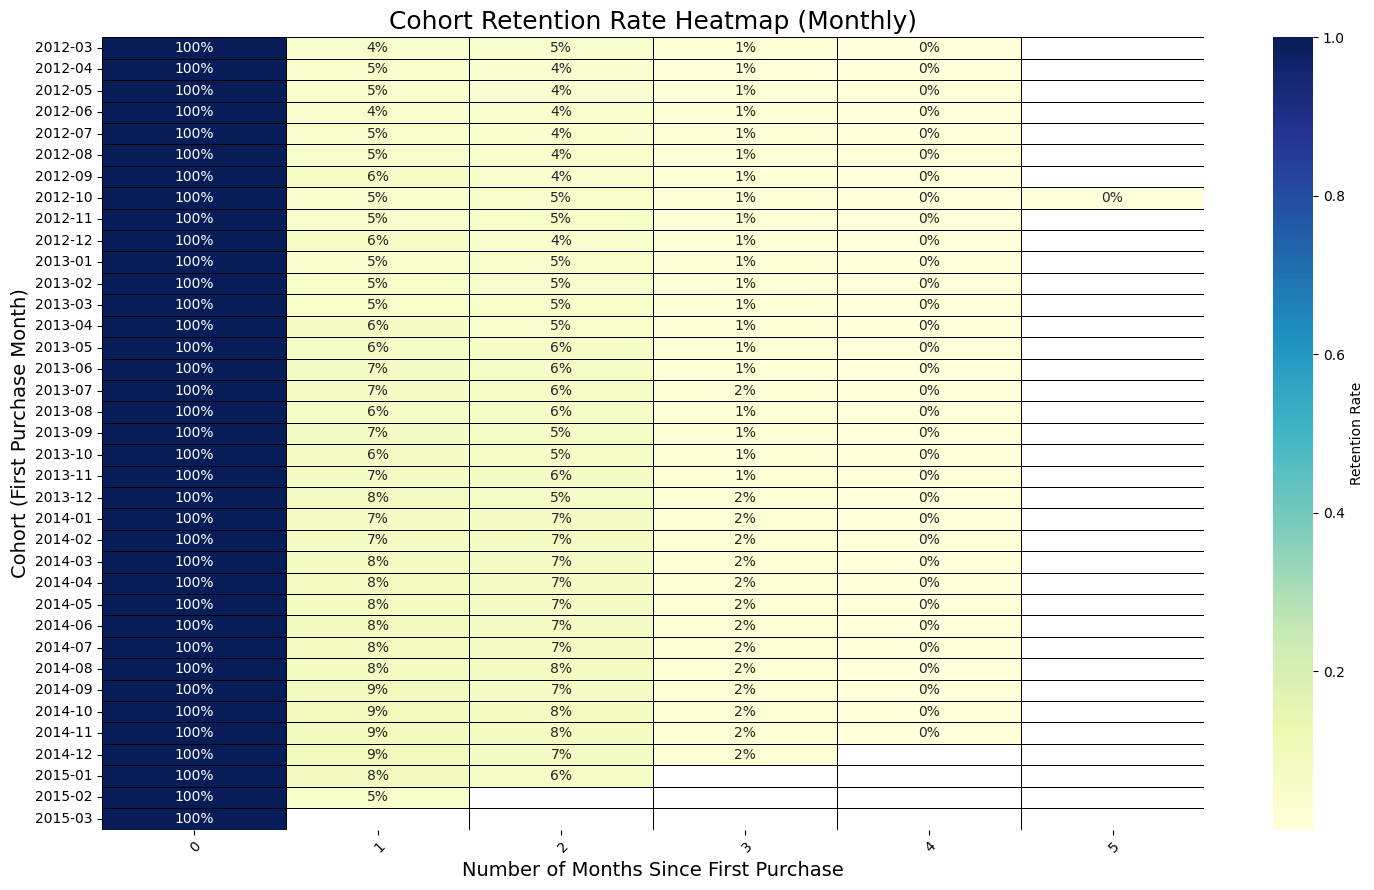

In [ ]:
# visualization (Retention Rate Heatmap)

# Calculate retention rate
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

# Prepare annotation strings for retention percentage
annot_retention = (retention_matrix.fillna(0) * 100).round(0).astype(int).astype(str) + '%'

# Create a mask for values where the retention is 0 to hide them in the heatmap
mask_retention = (retention_matrix.fillna(0) == 0)

# Set up the matplotlib figure and axes for the retention heatmap
fig, ax = plt.subplots(figsize=(15, 9)) # Adjust figure size as needed

# Create the retention heatmap
sns.heatmap(
    retention_matrix, # Use retention_matrix for color mapping
    annot=annot_retention,   # Use percentage annotations
    fmt='',           # No automatic formatting
    cmap='YlGnBu',    # Color map
    linewidths=.5,    # Lines between cells
    linecolor='black',
    cbar_kws={'label': 'Retention Rate'},
    mask=mask_retention,        # Apply the mask
    ax=ax             # Pass the axes object to seaborn
)

# Customize the plot
plt.title('Cohort Retention Rate Heatmap (Monthly)', fontsize=18)
plt.xlabel('Number of Months Since First Purchase', fontsize=14)
plt.ylabel('Cohort (First Purchase Month)', fontsize=14)
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout
plt.show()

**1. High Post-Acquisition Churn:**

We are witnessing an aggressive "leaky bucket" syndrome. Retention plummets from 100% at the initial acquisition to a range of 4% - 9% in Month 1. This suggests that the majority of our customer base is comprised of one-time buyers who do not find sufficient value or incentive to return.

**2. Positive Longitudinal Trend:** Despite the low absolute numbers, there is a clear upward trajectory in early-stage retention (Month 1) between 2012 (4% - 5%) and 2014 (8% - 9%). This indicates that recent product enhancements, CRM efforts, or improved customer experience initiatives are beginning to have a measurable impact.

## **Cohort by Source**


In [ ]:
source = sessions[['user_id', 'created_at', 'utm_source']]
source

,user_id,created_at,utm_source
0,1,2012-03-19 08:04:16,gsearch
1,2,2012-03-19 08:16:49,gsearch
2,3,2012-03-19 08:26:55,gsearch
3,4,2012-03-19 08:37:33,gsearch
4,5,2012-03-19 09:00:55,gsearch
...,...,...,...
472866,394314,2015-03-19 07:49:25,gsearch
472867,394315,2015-03-19 07:54:36,bsearch
472868,394316,2015-03-19 07:55:40,gsearch
472869,394317,2015-03-19 07:56:29,gsearch


In [ ]:
# First enroll
first_time_source = source.groupby(by = 'user_id', as_index = False).agg(First_time = ('created_at', 'min'))
first_time_source['Month'] = first_time_source['First_time'].dt.to_period('M')
first_time_source

,user_id,First_time,Month
0,1,2012-03-19 08:04:16,2012-03
1,2,2012-03-19 08:16:49,2012-03
2,3,2012-03-19 08:26:55,2012-03
3,4,2012-03-19 08:37:33,2012-03
4,5,2012-03-19 09:00:55,2012-03
...,...,...,...
394313,394314,2015-03-19 07:49:25,2015-03
394314,394315,2015-03-19 07:54:36,2015-03
394315,394316,2015-03-19 07:55:40,2015-03
394316,394317,2015-03-19 07:56:29,2015-03


In [ ]:
# join table
cohort_source = pd.merge(source, first_time_source, how = 'left', left_on = 'user_id', right_on = 'user_id')
cohort_source

,user_id,created_at,utm_source,First_time,Month
0,1,2012-03-19 08:04:16,gsearch,2012-03-19 08:04:16,2012-03
1,2,2012-03-19 08:16:49,gsearch,2012-03-19 08:16:49,2012-03
2,3,2012-03-19 08:26:55,gsearch,2012-03-19 08:26:55,2012-03
3,4,2012-03-19 08:37:33,gsearch,2012-03-19 08:37:33,2012-03
4,5,2012-03-19 09:00:55,gsearch,2012-03-19 09:00:55,2012-03
...,...,...,...,...,...
472866,394314,2015-03-19 07:49:25,gsearch,2015-03-19 07:49:25,2015-03
472867,394315,2015-03-19 07:54:36,bsearch,2015-03-19 07:54:36,2015-03
472868,394316,2015-03-19 07:55:40,gsearch,2015-03-19 07:55:40,2015-03
472869,394317,2015-03-19 07:56:29,gsearch,2015-03-19 07:56:29,2015-03


In [ ]:
# calculate the number of month to return
cohort_source['Cohort_Month'] = (cohort_source['created_at'].dt.year - cohort_source['Month'].dt.year) * 12 + (cohort_source['created_at'].dt.month - cohort_source['Month'].dt.month)
cohort_source

,user_id,created_at,utm_source,First_time,Month,Cohort_Month
0,1,2012-03-19 08:04:16,gsearch,2012-03-19 08:04:16,2012-03,0
1,2,2012-03-19 08:16:49,gsearch,2012-03-19 08:16:49,2012-03,0
2,3,2012-03-19 08:26:55,gsearch,2012-03-19 08:26:55,2012-03,0
3,4,2012-03-19 08:37:33,gsearch,2012-03-19 08:37:33,2012-03,0
4,5,2012-03-19 09:00:55,gsearch,2012-03-19 09:00:55,2012-03,0
...,...,...,...,...,...,...
472866,394314,2015-03-19 07:49:25,gsearch,2015-03-19 07:49:25,2015-03,0
472867,394315,2015-03-19 07:54:36,bsearch,2015-03-19 07:54:36,2015-03,0
472868,394316,2015-03-19 07:55:40,gsearch,2015-03-19 07:55:40,2015-03,0
472869,394317,2015-03-19 07:56:29,gsearch,2015-03-19 07:56:29,2015-03,0


In [ ]:
# pivot table
cohort_source_pivot = cohort_source.pivot_table(index = 'utm_source', columns = 'Cohort_Month', values = 'user_id', aggfunc = 'nunique')
cohort_source_pivot

Cohort_Month,0,1,2,3,4,5
utm_source,,,,,,
Organic,37254.0,19137.0,16333.0,4030.0,520.0,1.0
bsearch,58416.0,2041.0,1725.0,444.0,43.0,NaN
gsearch,295566.0,8192.0,7159.0,1924.0,203.0,NaN
socialbook,10685.0,NaN,NaN,NaN,NaN,NaN


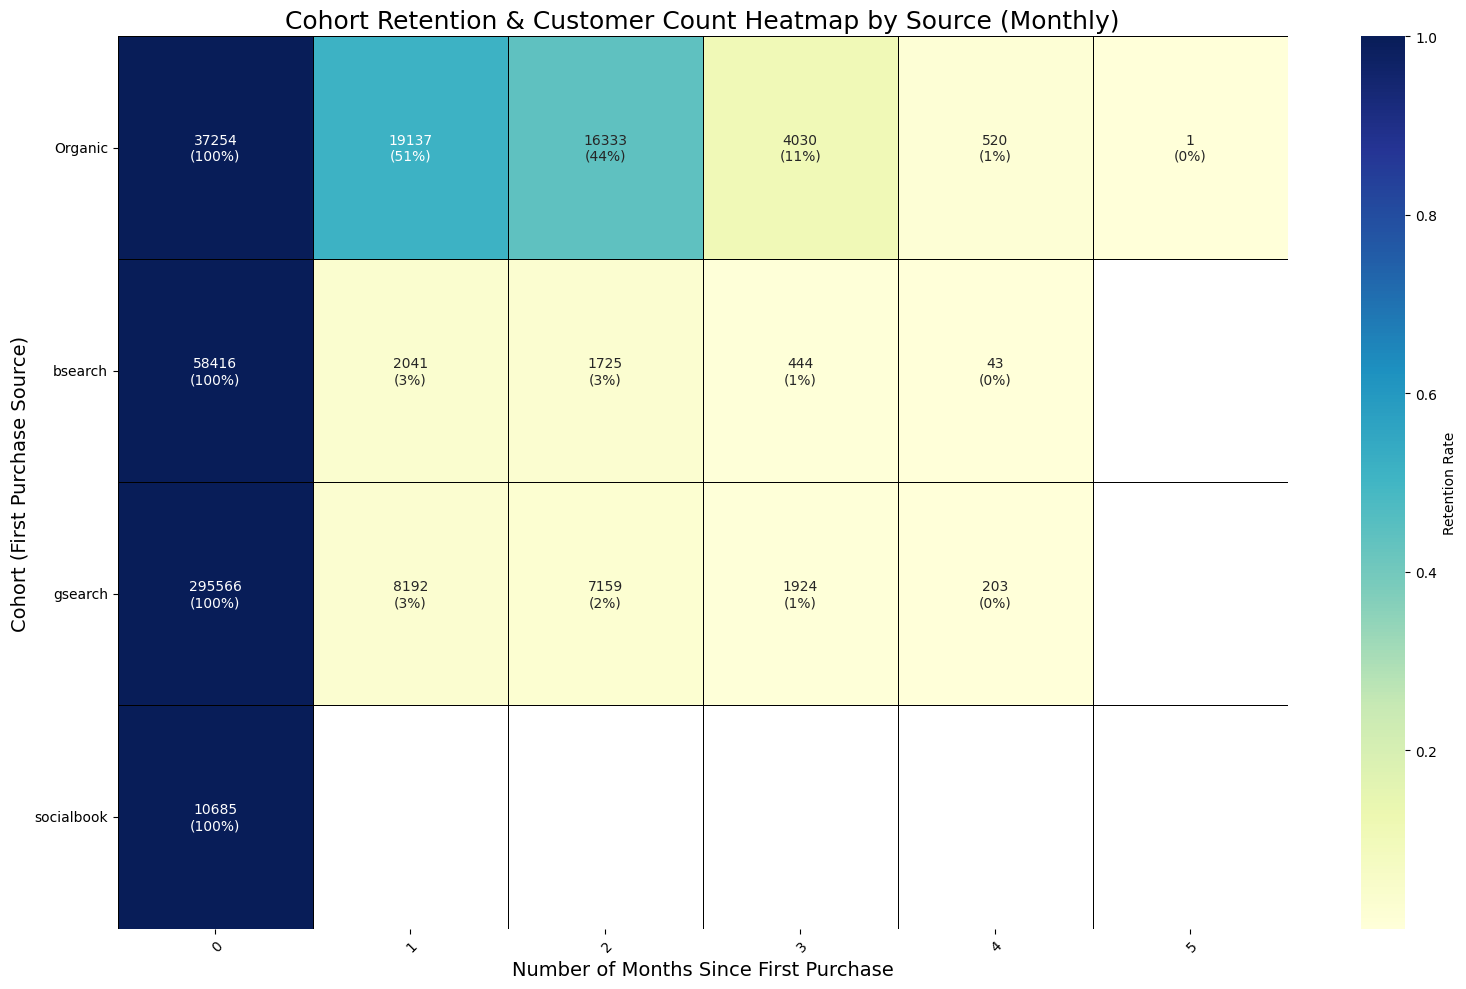

In [ ]:
cohort_source_sizes = cohort_source_pivot.iloc[:, 0]
retention_source_matrix = cohort_source_pivot.divide(cohort_source_sizes, axis=0)

# Fill NaN values with 0 for consistent formatting in annotations
retention_source_for_annot = retention_source_matrix.fillna(0)
cohort_source_pivot_for_annot = cohort_source_pivot.fillna(0)

# Prepare annotation strings: 'Count\nPercentage'
annot_source_df = cohort_source_pivot_for_annot.astype(int).astype(str) + '\n(' + \
                    (retention_source_for_annot * 100).round(0).astype(int).astype(str) + '%)'

# Create a mask for values where the count is 0 (or retention is 0) to make them white
mask_combined_source = (cohort_source_pivot_for_annot == 0)

# Set up the matplotlib figure and axes for the heatmap
fig, ax = plt.subplots(figsize=(16, 10)) # Adjust figure size as needed

sns.heatmap(
    retention_source_matrix, # Use retention_matrix for color mapping
    annot=annot_source_df,   # Use the combined annotation DataFrame
    fmt='',                   # No automatic formatting, as we provide custom strings
    cmap='YlGnBu',            # Color map
    linewidths=.5,            # Lines between cells
    linecolor='black',
    cbar_kws={'label': 'Retention Rate'},
    mask=mask_combined_source, # Apply the mask to hide cells with zero counts/retention
    ax=ax                     # Pass the axes object to seaborn
)

# Customize the plot
plt.title('Cohort Retention & Customer Count Heatmap by Source (Monthly)', fontsize=18)
plt.xlabel('Number of Months Since First Purchase', fontsize=14)
plt.ylabel('Cohort (First Purchase Source)', fontsize=14)
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout
plt.show()

**1. The "Organic" Outlier:**

* The "Organic" source is an **extreme outlier**. With a 51% retention rate in Month 1 and 44% in Month 2, it **significantly outperforms** all paid search channels (bsearch, gsearch).

→ Customers acquired organically have a vastly higher brand affinity and trust. They are not merely responding to a temporary price promotion; they likely found your brand via high-intent search or direct brand loyalty.

**2. Paid Search Performance:**

* `gsearch` and `bsearch` command the **highest volume** (over 350,000 combined initial customers) but suffer from abysmal retention—dropping to just 3% by Month 1.

→  Current paid acquisition strategy is optimized for Customer Acquisition Cost rather than Customer Lifetime Value. These channels are likely attracting "deal seekers" or customers looking for a specific item who have no intention of becoming repeat buyers.

**3. The `Socialbook` Gap**

* With **roughly 10,000 customers** but **0% retention** beyond Month 0, "socialbook" is currently a purely transactional channel.

→  If the acquisition cost for `socialbook` is low, keep it as a volume play. However, if paying a premium to acquire these customers, the ROI is likely negative due to the lack of repeat purchases.

## **Cohort by Device**

In [ ]:
device = sessions[['user_id', 'created_at', 'device_type']]
device

,user_id,created_at,device_type
0,1,2012-03-19 08:04:16,mobile
1,2,2012-03-19 08:16:49,desktop
2,3,2012-03-19 08:26:55,desktop
3,4,2012-03-19 08:37:33,desktop
4,5,2012-03-19 09:00:55,mobile
...,...,...,...
472866,394314,2015-03-19 07:49:25,desktop
472867,394315,2015-03-19 07:54:36,mobile
472868,394316,2015-03-19 07:55:40,mobile
472869,394317,2015-03-19 07:56:29,desktop


In [ ]:
# First enroll
first_time_device = source.groupby(by = 'user_id', as_index = False).agg(First_time = ('created_at', 'min'))
first_time_device['Month'] = first_time_source['First_time'].dt.to_period('M')
first_time_device

,user_id,First_time,Month
0,1,2012-03-19 08:04:16,2012-03
1,2,2012-03-19 08:16:49,2012-03
2,3,2012-03-19 08:26:55,2012-03
3,4,2012-03-19 08:37:33,2012-03
4,5,2012-03-19 09:00:55,2012-03
...,...,...,...
394313,394314,2015-03-19 07:49:25,2015-03
394314,394315,2015-03-19 07:54:36,2015-03
394315,394316,2015-03-19 07:55:40,2015-03
394316,394317,2015-03-19 07:56:29,2015-03


In [ ]:
# join table
cohort_device = pd.merge(device, first_time_device, how = 'left', left_on = 'user_id', right_on = 'user_id')
cohort_device

,user_id,created_at,device_type,First_time,Month
0,1,2012-03-19 08:04:16,mobile,2012-03-19 08:04:16,2012-03
1,2,2012-03-19 08:16:49,desktop,2012-03-19 08:16:49,2012-03
2,3,2012-03-19 08:26:55,desktop,2012-03-19 08:26:55,2012-03
3,4,2012-03-19 08:37:33,desktop,2012-03-19 08:37:33,2012-03
4,5,2012-03-19 09:00:55,mobile,2012-03-19 09:00:55,2012-03
...,...,...,...,...,...
472866,394314,2015-03-19 07:49:25,desktop,2015-03-19 07:49:25,2015-03
472867,394315,2015-03-19 07:54:36,mobile,2015-03-19 07:54:36,2015-03
472868,394316,2015-03-19 07:55:40,mobile,2015-03-19 07:55:40,2015-03
472869,394317,2015-03-19 07:56:29,desktop,2015-03-19 07:56:29,2015-03


In [ ]:
# calculate the number of month to return
cohort_device['Cohort_Month'] = (cohort_device['created_at'].dt.year - cohort_device['Month'].dt.year) * 12 + (cohort_device['created_at'].dt.month - cohort_device['Month'].dt.month)
cohort_device

,user_id,created_at,device_type,First_time,Month,Cohort_Month
0,1,2012-03-19 08:04:16,mobile,2012-03-19 08:04:16,2012-03,0
1,2,2012-03-19 08:16:49,desktop,2012-03-19 08:16:49,2012-03,0
2,3,2012-03-19 08:26:55,desktop,2012-03-19 08:26:55,2012-03,0
3,4,2012-03-19 08:37:33,desktop,2012-03-19 08:37:33,2012-03,0
4,5,2012-03-19 09:00:55,mobile,2012-03-19 09:00:55,2012-03,0
...,...,...,...,...,...,...
472866,394314,2015-03-19 07:49:25,desktop,2015-03-19 07:49:25,2015-03,0
472867,394315,2015-03-19 07:54:36,mobile,2015-03-19 07:54:36,2015-03,0
472868,394316,2015-03-19 07:55:40,mobile,2015-03-19 07:55:40,2015-03,0
472869,394317,2015-03-19 07:56:29,desktop,2015-03-19 07:56:29,2015-03,0


In [ ]:
# pivot table
cohort_device_pivot = cohort_device.pivot_table(index = 'device_type', columns = 'Cohort_Month', values = 'user_id', aggfunc = 'nunique')
cohort_device_pivot

Cohort_Month,0,1,2,3,4,5
device_type,,,,,,
desktop,279256.0,18295.0,15511.0,3908.0,454.0,NaN
mobile,119733.0,11006.0,9490.0,2443.0,307.0,1.0


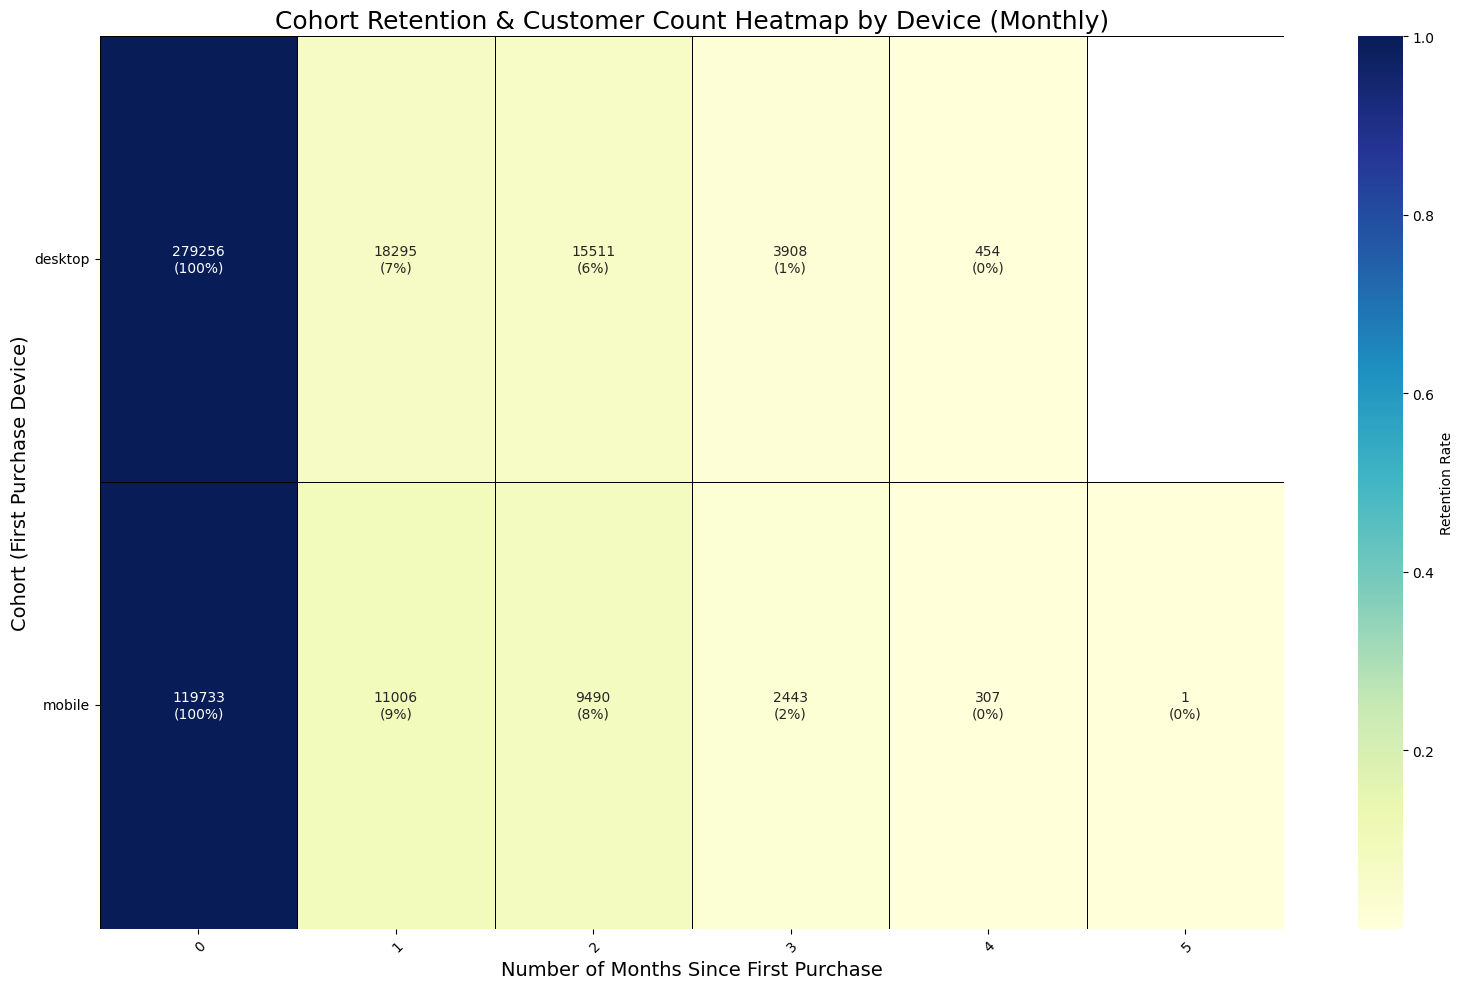

In [ ]:
cohort_device_sizes = cohort_device_pivot.iloc[:, 0]
retention_device_matrix = cohort_device_pivot.divide(cohort_device_sizes, axis=0)

# Fill NaN values with 0 for consistent formatting in annotations
retention_device_for_annot = retention_device_matrix.fillna(0)
cohort_device_pivot_for_annot = cohort_device_pivot.fillna(0)

# Prepare annotation strings: 'Count\nPercentage'
annot_device_df = cohort_device_pivot_for_annot.astype(int).astype(str) + '\n(' + \
                    (retention_device_for_annot * 100).round(0).astype(int).astype(str) + '%)'

# Create a mask for values where the count is 0 (or retention is 0) to make them white
mask_combined_device = (cohort_device_pivot_for_annot == 0)

# Set up the matplotlib figure and axes for the heatmap
fig, ax = plt.subplots(figsize=(16, 10)) # Adjust figure size as needed

sns.heatmap(
    retention_device_matrix, # Use retention_matrix for color mapping
    annot=annot_device_df,   # Use the combined annotation DataFrame
    fmt='',                   # No automatic formatting, as we provide custom strings
    cmap='YlGnBu',            # Color map
    linewidths=.5,            # Lines between cells
    linecolor='black',
    cbar_kws={'label': 'Retention Rate'},
    mask=mask_combined_device, # Apply the mask to hide cells with zero counts/retention
    ax=ax                     # Pass the axes object to seaborn
)

# Customize the plot
plt.title('Cohort Retention & Customer Count Heatmap by Device (Monthly)', fontsize=18)
plt.xlabel('Number of Months Since First Purchase', fontsize=14)
plt.ylabel('Cohort (First Purchase Device)', fontsize=14)
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout
plt.show()

# **6. Recommendation**



**6.1. Homepage Optimization**

The **93% bounce rate** at the `/home` page is your most critical **"emergency"**. You are successfully driving top-of-funnel traffic, but losing them instantly.

* **Implement A/B testing on the homepage**. Shift the hero section to feature **"The Original Mr. Fuzzy"** directly. High-intent traffic from organic sources should be met with the product they are looking for, not a generic landing page.

* High bounce rates are often related to page load speeds on different devices. D**esktop access rates are higher than mobile access rates**; however, **the retention rate for mobile devices is not significantly higher**. Therefore, image optimization for each access device is necessary.

* Create dedicated landing pages for specific search keywords (if a user searches for "plush toys," send them to the collection page, not the homepage).

**6.2. Implement a Source-Specific Lifecycle Strategy**

* **For the "Loyal" Organic Traffic:** These users have high affinity ⟹ Move them into a "Loyalty Program" or "Subscriber List." Since they return, treat them with personalized product recommendations and exclusive early access to new items to build brand equity.

* **For the "Transactional" Paid Search (gsearch/bsearch):** Shift from **acquisition-only** to **conversion-focused**. Since they leave after one purchase, **implement an automated re-engagement sequence**(a "Welcome Back" email with a 15% discount for a second purchase) triggered exactly 14 days after their first delivery.

**6.3. Strategic Budget Reallocation**

* If the cost to acquire a `gsearch` user is high and they never return, stop bidding on high-volume, generic keywords that only bring deal-seekers.

* Reallocate that budget into Content Marketing/SEO for your top-performing organic keywords. Long-term, high-retention traffic will yield a much higher ROI than constantly paying for rented traffic that leaves after a month.